# Volatility Term Structure Engine — Prediction Market Series

End-to-end walkthrough of the pipeline (see `CLAUDE.md` for the spec and `docs/2510.15205v2.pdf` for the model).

**What we're doing:** take a *series market* (the same event at several deadlines), convert prices to log-odds, estimate belief volatility per deadline, fit a smooth term structure, and read off a **fair price for any unlisted date**.

Each module is exercised in its own section:
- `config` — loads API secrets from `.env`
- `transforms` — logit/sigmoid math (the log-odds world)
- `fireplace` — the API client
- `termstructure` — the engine: build table, fit curves, interpolate

In [1]:
# Setup: imports + confirm credentials loaded from .env (never printed in full)
import warnings
import numpy as np, pandas as pd

import config
import transforms as T
from fireplace import FireplaceClient
from termstructure import build_term_structure, TermStructure, DataQualityWarning

# Quiet generic numeric warnings, but ALWAYS surface our data-quality warnings
# (e.g. a market with a wrong endDate that we recover from the question text).
warnings.simplefilter("ignore")
warnings.simplefilter("always", DataQualityWarning)

print("API key loaded:", config.FIREPLACE_API_KEY is not None and len(config.FIREPLACE_API_KEY) > 0)

# The series event we analyze. Swap this id for any "... by <date>?" series.
# 357807 = "US x Iran permanent peace deal by ...?"  (found via search, below)
EVENT_ID = "357807"

API key loaded: True


## 0. (optional) Find a series with search
A *series* event is one underlying question at many deadlines — its title usually ends in `by ...?`. Run this to discover event ids, then set `EVENT_ID` above.

In [2]:
fc = FireplaceClient()
hits = fc.search_events("by", limit=25)
# Show events whose title looks like a temporal series and that have several markets.
series = [h for h in hits if str(h.get("event_title", "")).strip().endswith("?") and (h.get("market_count") or 0) >= 3]
for h in series[:10]:
    print(h["event_id"], "|", h.get("market_count"), "mkts |", h.get("event_title"))

357807 | 6 mkts | US x Iran permanent peace deal by...?
90177 | 3 mkts | Will the US confirm that aliens exist by...?
517606 | 4 mkts | US announces new Iran agreement/ceasefire extension by...?
102007 | 16 mkts | SpaceX IPO closing market cap above ___ ?
438327 | 3 mkts | Iran closes its airspace by...?
574642 | 3 mkts | Trump announces US x Iran ceasefire over by...?
449163 | 6 mkts | Israel closes its airspace by...?
125877 | 23 mkts | Will Crude Oil (CL) hit__ by end of June?
235450 | 32 mkts | Where will George Pickens play in 2026-27?
212173 | 14 mkts | Which NFL players will be traded?


## 1. `transforms` — the log-odds world
Why log-odds? A 1-cent move means something very different at p=0.50 vs p=0.02. The logit map stretches (0,1) onto the whole real line so movement is comparable everywhere, and lets us use standard diffusion math.

Run/test: `uv run python -c "import transforms as T; print(T.logit(0.5), T.sigmoid(0.0), T.s_prime(0.0))"`

In [3]:
# logit and sigmoid are inverses; S'(x)=p(1-p) peaks at p=0.5; RN drift keeps p a martingale.
for p in [0.05, 0.3, 0.5, 0.7]:
    x = float(T.logit(p))
    print(f"p={p:>4} -> x={x:+.3f} -> back to p={float(T.sigmoid(x)):.3f} | "
          f"S'(x)={float(T.s_prime(x)):.3f} | RN drift(sigma_b=1)={float(T.rn_drift_diffusion(p,1.0)):+.3f}")

p=0.05 -> x=-2.944 -> back to p=0.050 | S'(x)=0.048 | RN drift(sigma_b=1)=-0.450
p= 0.3 -> x=-0.847 -> back to p=0.300 | S'(x)=0.210 | RN drift(sigma_b=1)=-0.200
p= 0.5 -> x=+0.000 -> back to p=0.500 | S'(x)=0.250 | RN drift(sigma_b=1)=-0.000
p= 0.7 -> x=+0.847 -> back to p=0.700 | S'(x)=0.210 | RN drift(sigma_b=1)=+0.200


## 2. `fireplace` — fetch the series and look at each deadline
Run/test: `uv run python -c "from fireplace import FireplaceClient as C; print(len(C().get_event_markets('357807')))"`

In [4]:
points = fc.get_event_markets(EVENT_ID)
print(f"{len(points)} markets in this event:\n")
for pt in sorted(points, key=lambda p: (p.end_date or __import__('datetime').datetime.max.replace(tzinfo=__import__('datetime').timezone.utc))):
    print(f"  {pt.label:>14} | end {pt.end_date} | yes={pt.yes_price}")

7 markets in this event:

          May 11 | end 2026-05-11 00:00:00+00:00 | yes=0.002007933333333267
         June 30 | end 2026-05-31 00:00:00+00:00 | yes=0.1700000009576923
         June 15 | end 2026-06-15 00:00:00+00:00 | yes=0.05000047500071236
         July 31 | end 2026-07-31 00:00:00+00:00 | yes=0.29000000000000004
       August 31 | end 2026-08-31 00:00:00+00:00 | yes=0.43000000000000005
      October 31 | end 2026-10-31 00:00:00+00:00 | yes=0.57
     December 31 | end 2026-12-31 00:00:00+00:00 | yes=0.6799999999999999


## 3. `termstructure` — build the table (steps 1-3 of the pipeline)
Keeps only **live** deadlines, converts price -> logit, and estimates belief volatility `sigma_b` from candles.

Two data-quality guards built into `build_term_structure`:
- **endDate cross-check**: every market's structured `endDate` is compared against the deadline written in its question text; when they disagree (like the June 30 market, stamped 2026-05-31 while trading at 16c) the question-text date wins and a `DataQualityWarning` says so.
- **Common vol window**: `sigma_b` is measured over the *same trailing 30 days* for every market. Markets listed at different times would otherwise mix in different volatility regimes — that artifact showed up as a fake vol "kink" at the Oct/Dec deadlines in v1 of this notebook.

Run/test: `uv run python -c "from fireplace import FireplaceClient; from termstructure import build_term_structure as b; print(b(FireplaceClient(),'357807'))"`

In [5]:
df = build_term_structure(fc, EVENT_ID)
df[["label", "end_date", "tau_years", "p", "x", "sigma_b", "api_volatility"]]

/var/folders/31/lcvbbhv96y73866tt781w03c0000gn/T/ipykernel_96240/3989227061.py:1: DataQualityWarning: Market 1962237 ('June 30'): endDate 2026-05-31 disagrees with deadline 2026-06-30 parsed from the question text. Using the question-text date.
  df = build_term_structure(fc, EVENT_ID)


,label,end_date,tau_years,p,x,sigma_b,api_volatility
0,June 15,2026-06-15 00:00:00+00:00,0.009678,0.05,-2.944429,12.722531,0.071264
1,June 30,2026-06-30 00:00:00+00:00,0.050745,0.17,-1.585627,8.598490,0.043014
2,July 31,2026-07-31 00:00:00+00:00,0.135619,0.29,-0.895384,8.461217,0.039994
3,August 31,2026-08-31 00:00:00+00:00,0.220492,0.43,-0.281851,4.716127,0.033838
4,October 31,2026-10-31 00:00:00+00:00,0.387501,0.57,0.281851,5.814578,0.047596
5,December 31,2026-12-31 00:00:00+00:00,0.554510,0.68,0.753772,6.380027,0.048625


## 4-5. Fit the curves and read off a fair price for an UNLISTED date
`fair_price_on_date(date)` is the headline deliverable `f(date) -> fair price`. The price level comes from monotone (PCHIP) interpolation of the listed logit-prices; `sigma_b` supplies the uncertainty band.

Run/test: `uv run python -c "from fireplace import *; from termstructure import *; ts=TermStructure.from_table(build_term_structure(FireplaceClient(),'357807')); print(ts.fair_price_on_date('2026-09-15'))"`

In [6]:
ts = TermStructure.from_table(df)

print("Fair price for unlisted dates (with 1-sigma / 7-day band):\n")
for d in ["2026-07-01", "2026-09-15", "2026-11-30"]:
    lo, mid, hi = ts.price_band(d, horizon_days=7)
    vol = float(ts.belief_vol(ts.years_until(d)))
    print(f"  {d}: fair={mid:.3f}  band=[{lo:.3f}, {hi:.3f}]  belief_vol={vol:.2f}/yr")

# Sanity: fair price must be monotone increasing in date (it's a CDF of event time).
grid = ["2026-06-20", "2026-08-01", "2026-10-01", "2026-12-15"]
prices = [ts.fair_price_on_date(d) for d in grid]
print("\nMonotone check:", list(zip(grid, [round(p, 3) for p in prices])),
      "-> increasing:", all(a <= b for a, b in zip(prices, prices[1:])))

Fair price for unlisted dates (with 1-sigma / 7-day band):

  2026-07-01: fair=0.175  band=[0.061, 0.411]  belief_vol=8.59/yr
  2026-09-15: fair=0.473  band=[0.315, 0.637]  belief_vol=4.85/yr
  2026-11-30: fair=0.628  band=[0.419, 0.798]  belief_vol=6.15/yr

Monotone check: [('2026-06-20', 0.084), ('2026-08-01', 0.294), ('2026-10-01', 0.51), ('2026-12-15', 0.654)] -> increasing: True


## 6. Sanity-check our `sigma_b` against the venue's own vol field
The two are in different units, so `vol_sanity_check` converts ours into theirs before comparing: ours is an annualized log-odds vol, the venue's behaves like a **daily price stdev**, and the bridge is `sigma_b * p(1-p) / sqrt(365)` (logit Jacobian + de-annualization). After conversion the ratio should be O(1) — far from ~1 flags an estimation problem on one side.

In [7]:
ts.vol_sanity_check(df)

,label,tau_years,p,sigma_b,api_volatility,ours_as_daily_price_vol,ratio_ours_to_api
0,June 15,0.009678,0.05,12.722531,0.071264,0.031621,0.443719
1,June 30,0.050745,0.17,8.598490,0.043014,0.063483,1.475852
2,July 31,0.135619,0.29,8.461217,0.039994,0.091158,2.279311
3,August 31,0.220492,0.43,4.716127,0.033838,0.060483,1.787430
4,October 31,0.387501,0.57,5.814578,0.047596,0.074570,1.566742
5,December 31,0.554510,0.68,6.380027,0.048625,0.072642,1.493906


## 7. Plot the term structure
`matplotlib` is installed. The red dots are the listed deadlines (now 6, including the June 30 market recovered by the `endDate` cross-check); the curve is the fitted fair-price term structure.

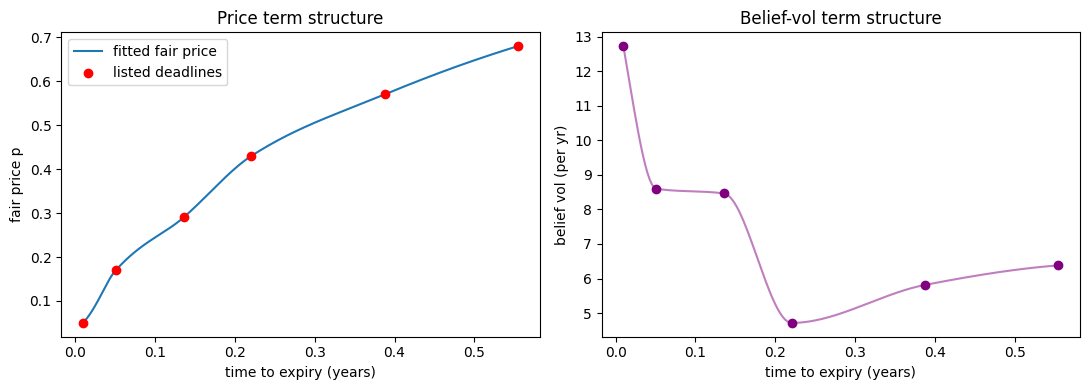

In [8]:
try:
    import matplotlib.pyplot as plt
    taus = np.linspace(df["tau_years"].min(), df["tau_years"].max(), 200)
    fig, ax = plt.subplots(1, 2, figsize=(11, 4))
    ax[0].plot(taus, ts.fair_price(taus), label="fitted fair price")
    ax[0].scatter(df["tau_years"], df["p"], color="red", zorder=5, label="listed deadlines")
    ax[0].set(xlabel="time to expiry (years)", ylabel="fair price p", title="Price term structure")
    ax[0].legend()
    ax[1].scatter(df["tau_years"], df["sigma_b"], color="purple")
    ax[1].plot(taus, [float(ts.belief_vol(t)) for t in taus], color="purple", alpha=0.5)
    ax[1].set(xlabel="time to expiry (years)", ylabel="belief vol (per yr)", title="Belief-vol term structure")
    plt.tight_layout(); plt.show()
except ModuleNotFoundError:
    print("matplotlib not installed. Run `uv add matplotlib` to enable plotting, then re-run this cell.")

## 8. Rich/cheap vs a parametric hazard fit — the trading view
PCHIP **interpolates**: it passes exactly through every listed price, so a listed market has zero residual by construction and can never look mispriced. `HazardFit` instead fits a 2-parameter Weibull hazard

$$p(\tau) = 1 - e^{-(\tau/\theta)^k}$$

by least squares in logit space. With 6 deadlines and 2 parameters there are real residuals left over: a market **above** the fitted curve is *rich* vs its siblings, **below** is *cheap*. The shape parameter is interpretable too: `k < 1` means a front-loaded hazard — the market believes "if a deal doesn't happen soon, it gets less likely per day".

theta=0.481 yr   k=0.765   (k<1 -> front-loaded hazard)



,label,tau_years,p,model_p,residual_cents,residual_logit,hazard_pct_per_day
0,June 15,0.009678,0.05,0.049219,0.078126,0.016570,1.091699
1,June 30,0.050745,0.17,0.164031,0.596896,0.042909,0.739057
2,July 31,0.135619,0.29,0.316065,-2.606522,-0.123470,0.586362
3,August 31,0.220492,0.43,0.423546,0.645449,0.026384,0.522964
4,October 31,0.387501,0.57,0.571622,-0.162163,-0.006619,0.457951
5,December 31,0.554510,0.68,0.672073,0.792672,0.036195,0.420898


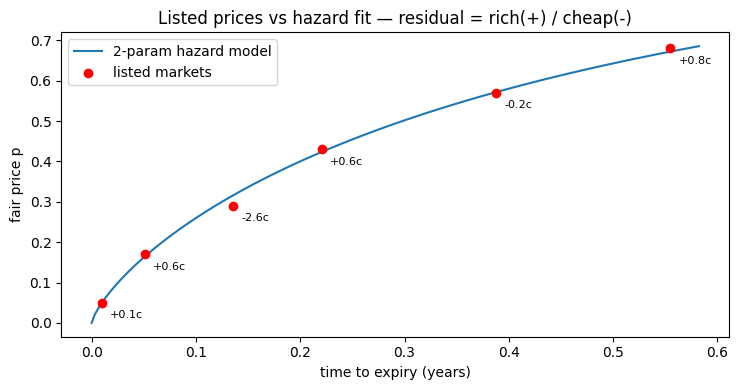

In [9]:
from termstructure import HazardFit

hz = HazardFit.fit(df["tau_years"], df["p"])
print(f"theta={hz.theta:.3f} yr   k={hz.k:.3f}   (k<1 -> front-loaded hazard)\n")
rc = hz.rich_cheap(df)
display(rc)

# Listed prices vs the fitted curve, with each market's residual annotated.
import matplotlib.pyplot as plt
taus = np.linspace(0.0, df["tau_years"].max() * 1.05, 200)
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(taus, hz.prob(taus), label="2-param hazard model")
ax.scatter(df["tau_years"], df["p"], color="red", zorder=5, label="listed markets")
for _, r in rc.iterrows():
    ax.annotate(f"{r['residual_cents']:+.1f}c", (r["tau_years"], r["p"]),
                textcoords="offset points", xytext=(6, -11), fontsize=8)
ax.set(xlabel="time to expiry (years)", ylabel="fair price p",
       title="Listed prices vs hazard fit — residual = rich(+) / cheap(-)")
ax.legend(); plt.tight_layout(); plt.show()

                    window | days | market %/day | model %/day
              now->June 15 |    4 |        1.415 |       1.285
          June 15->June 30 |   15 |        0.842 |       0.835
          June 30->July 31 |   31 |        0.466 |       0.641
        July 31->August 31 |   31 |        0.636 |       0.550
     August 31->October 31 |   61 |        0.403 |       0.485
   October 31->December 31 |   61 |        0.419 |       0.437


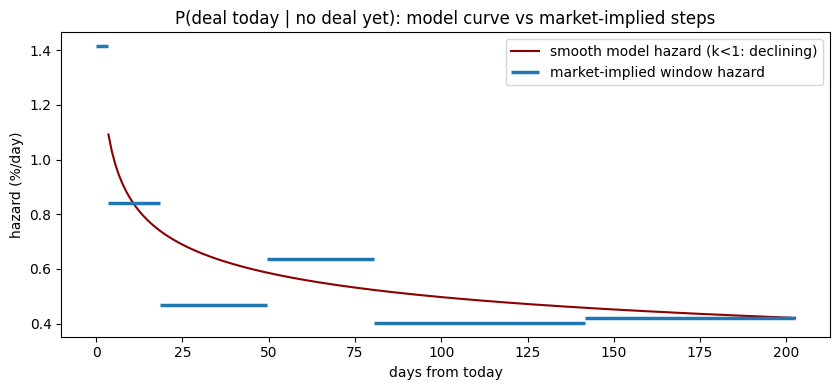

In [10]:
# The hazard curve in one picture: "chance of a deal per day, GIVEN no deal yet".
#
#  - solid red line = the fitted Weibull model's hazard. k<1 makes it slope
#    down: the model's whole worldview is "momentum fades".
#  - blue steps = the MARKET's implied hazard for each window between
#    deadlines, computed model-free from prices alone:
#        h = (p_later - p_earlier) / ((1 - p_earlier) * days_in_window)
#    "the extra probability the later contract buys, divided by the chance we
#    even reach that window, per day".
#
# Reading it: a step ABOVE the line = the market packs more per-day chance
# into that window than the smooth story allows (a catalyst window). BELOW =
# a lull. This localizes WHERE on the calendar market and model disagree —
# Section 8's residuals say "which contract", this says "which weeks".
fig, ax = plt.subplots(figsize=(8.5, 4))
gtau = np.linspace(df["tau_years"].min(), df["tau_years"].max(), 200)
ax.plot(gtau * 365.25, hz.hazard_pct_per_day(gtau), color="darkred",
        label="smooth model hazard (k<1: declining)")

edges_tau = np.concatenate([[0.0], df["tau_years"].to_numpy()])
edges_p = np.concatenate([[0.0], df["p"].to_numpy()])
names = [f"now->{df['label'].iloc[0]}"] + \
        [f"{a}->{b}" for a, b in zip(df["label"], df["label"].iloc[1:])]
print(f"{'window':>26} | {'days':>4} | market %/day | model %/day")
for i in range(len(df)):
    days = (edges_tau[i + 1] - edges_tau[i]) * 365.25
    h_mkt = 100.0 * (edges_p[i + 1] - edges_p[i]) / ((1.0 - edges_p[i]) * days)
    h_mod = float(hz.hazard_pct_per_day(0.5 * (edges_tau[i] + edges_tau[i + 1])))
    print(f"{names[i]:>26} | {days:4.0f} | {h_mkt:12.3f} | {h_mod:11.3f}")
    ax.hlines(h_mkt, edges_tau[i] * 365.25, edges_tau[i + 1] * 365.25,
              color="tab:blue", lw=2.5,
              label="market-implied window hazard" if i == 0 else None)
ax.set(xlabel="days from today", ylabel="hazard (%/day)",
       title="P(deal today | no deal yet): model curve vs market-implied steps")
ax.legend(); plt.tight_layout(); plt.show()

## 9. Microstructure — can we actually get filled, and where do we make vs take?
A rich/cheap signal is worthless if you can't trade it for less than the edge. Before designing a make+take strategy we profile each deadline's **tape**: how often it trades, in what size, against which makers, and at what effective spread (read off alternating trade prints — the external API exposes trades and candles but no order-book depth).

How to read it for strategy:
- **High trade rate + small median size** = lots of retail flow to interact with -> *make* there (post limit orders on the side the hazard model favors and let flow come to you).
- **Low trade rate** = a resting order sits unfilled; if the model signal is there you may have to *take* and pay the spread — only worth it when the residual comfortably exceeds spread + fees.
- Trades are tagged `outcome` Yes/No; No prints are converted to Yes-equivalent (`1 - price`) so everything plots on one scale.

In [11]:
# Liquidity profile per deadline, from the last 500 trade prints of each market.
from datetime import datetime, timezone

now_ts = datetime.now(timezone.utc).timestamp()
trades_by_label = {}
liq_rows = []
for _, r in df.iterrows():
    trades = fc.recent_trades(r["market_id"], limit=500)
    trades_by_label[r["label"]] = trades
    t = np.array([tr["timestamp"] for tr in trades], float)
    # The leg with asset_id "0" is cash, so that amount is the trade's USD notional.
    usd = np.array([float(tr["maker_amount"] if tr["maker_asset_id"] == "0"
                          else tr["taker_amount"]) / 1e6 for tr in trades])
    span_h = max((t.max() - t.min()) / 3600.0, 0.01)
    liq_rows.append({
        "label": r["label"],
        "trades_per_hr": len(trades) / span_h,
        "usd_per_day": usd.sum() / (span_h / 24.0),
        "median_trade_usd": float(np.median(usd)),
        "min_since_last_trade": (now_ts - t.max()) / 60.0,
        "distinct_makers": len({tr.get("maker_username") or tr["maker"] for tr in trades}),
    })
liq = pd.DataFrame(liq_rows)
display(liq.round(1))

,label,trades_per_hr,usd_per_day,median_trade_usd,min_since_last_trade,distinct_makers
0,June 15,351.0,741551.2,5.4,1.0,148
1,June 30,100.8,1157369.2,16.4,2.9,185
2,July 31,42.0,187963.0,14.2,23.3,183
3,August 31,15.4,50834.1,9.3,16.5,169
4,October 31,11.8,40854.9,10.0,16.6,150
5,December 31,60.6,156232.0,8.0,28.2,142


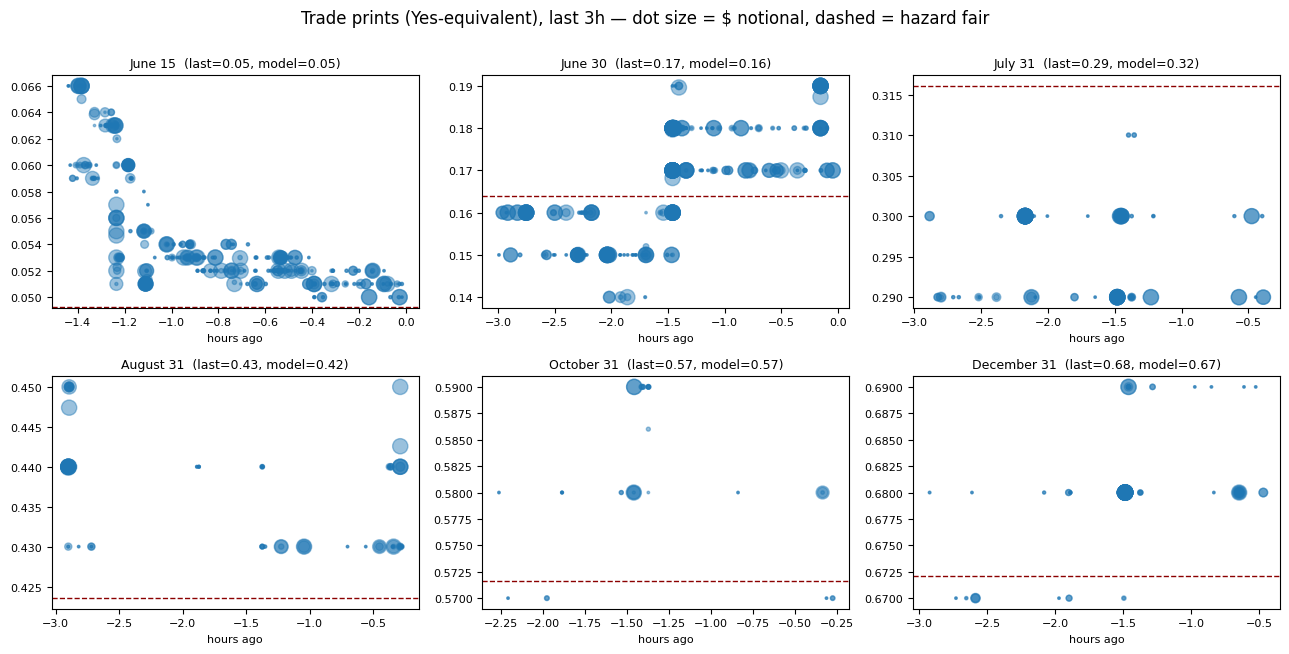

price levels printed in the last hour (Yes-equivalent):
       June 15: [0.05, 0.051, 0.052, 0.053, 0.054]
       June 30: [0.17, 0.18, 0.187, 0.19]
       July 31: [0.29, 0.3]
     August 31: [0.43, 0.44, 0.443, 0.45]
    October 31: [0.57, 0.58]
   December 31: [0.68, 0.69]


In [12]:
# The tape, per deadline: every print in the last 3 hours, Yes-equivalent.
# Dot size ~ USD notional; the dashed line is the hazard-model fair price.
# Wide scatter between the two price levels = the effective bid/ask; a one-
# sided stream = flow hitting one quote (that's the side a maker would join).
import matplotlib.pyplot as plt

CUTOFF_H = 3.0
fig, axes = plt.subplots(2, 3, figsize=(13, 6.5))
for ax, (_, r) in zip(axes.flat, df.iterrows()):
    trades = trades_by_label[r["label"]]
    t = np.array([tr["timestamp"] for tr in trades], float)
    p = np.array([tr["trade_price"] if tr["outcome"] == "Yes"
                  else 1.0 - tr["trade_price"] for tr in trades])
    usd = np.array([float(tr["maker_amount"] if tr["maker_asset_id"] == "0"
                          else tr["taker_amount"]) / 1e6 for tr in trades])
    keep = (now_ts - t) <= CUTOFF_H * 3600
    if not keep.any():          # nothing in window -> show most recent 50 prints
        keep = np.argsort(t)[-50:]
    hrs_ago = (t[keep] - now_ts) / 3600.0
    ax.scatter(hrs_ago, p[keep], s=np.clip(usd[keep], 3, 120), alpha=0.45)
    model_fair = float(hz.prob(r["tau_years"]))
    ax.axhline(model_fair, ls="--", lw=1, color="darkred")
    ax.set_title(f"{r['label']}  (last={r['p']:.2f}, model={model_fair:.2f})", fontsize=9)
    ax.set_xlabel("hours ago", fontsize=8)
    ax.tick_params(labelsize=8)
fig.suptitle("Trade prints (Yes-equivalent), last 3h — dot size = $ notional, dashed = hazard fair", y=1.0)
plt.tight_layout(); plt.show()

# Effective spread proxy: distinct price levels traded in the last hour.
print("price levels printed in the last hour (Yes-equivalent):")
for _, r in df.iterrows():
    trades = trades_by_label[r["label"]]
    px = sorted({round(tr["trade_price"] if tr["outcome"] == "Yes" else 1 - tr["trade_price"], 3)
                 for tr in trades if now_ts - tr["timestamp"] <= 3600})
    print(f"  {r['label']:>12}: {px if px else 'no trades in the last hour'}")

## 10. Signal discipline — is today's residual a trade, or just the model being wrong?
A raw residual is not a signal. Three problems, three fixes, all in `termstructure.py`:

1. **The model may be wrong, not the market.** `residual_history()` refits the hazard model at every 4h step of the past 30 days (prices rebuilt from candles, time-to-expiry recomputed as-of each step), so today's residual is judged against **its own history** via a z-score. A market that is *chronically* +2c rich has z ≈ 0 — that's a model blind spot, not a trade. A market that jumped from 0 to +2c **yesterday** has a big z — that's a dislocation.
2. **Edge must beat the toll.** `effective_spread_cents()` reads each market's bid/ask off the tape; `residual_signals()` computes net edge for making (keep it all) vs taking (pay the spread).
3. **Small numbers are noise.** An actionable call requires BOTH |z| ≥ 2 AND make-edge ≥ max(1.5c, spread). Anything else is explicitly labeled no-trade, with the reason.

Run/test: `uv run python -c "from fireplace import *; from termstructure import *; print(residual_history(FireplaceClient(),'357807',days=30).tail())"`

termstructure.py:532: DataQualityWarning: Market 1962237 ('June 30'): endDate 2026-05-31 disagrees with deadline 2026-06-30 parsed from the question text. Using the question-text date.
  base = build_term_structure(client, event_id, now=now, estimate_vol=False)


160 historical fits



,label,residual_c,hist_mean_c,hist_std_c,z,spread_c,edge_make_c,edge_take_c,action
0,June 15,0.08,-1.25,1.25,1.06,0.4,0.08,-0.32,no-trade (noise)
1,June 30,0.60,0.69,1.41,-0.07,2.0,0.60,-1.40,no-trade (noise)
2,July 31,-2.61,1.73,2.57,-1.69,1.0,2.61,1.61,"no-trade (chronic: model blind spot, not a dis..."
3,December 31,0.79,-0.85,0.78,2.10,1.0,0.79,-0.21,no-trade (dislocated but edge below cost floor)
4,August 31,0.65,1.10,0.96,-0.47,2.0,0.65,-1.35,no-trade (noise)
5,October 31,-0.16,-0.03,0.95,-0.14,1.0,0.16,-0.84,no-trade (noise)


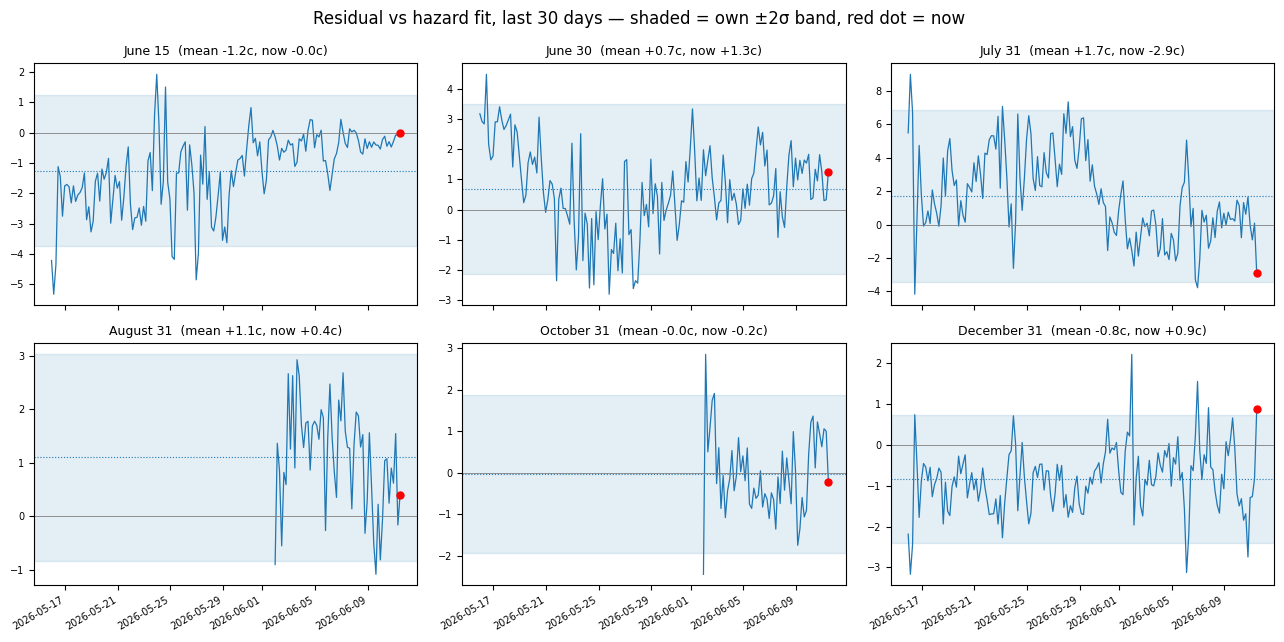

In [13]:
from termstructure import residual_history, residual_signals, effective_spread_cents

# 1) Backfill: refit the hazard model every 4h over the past 30 days.
hist = residual_history(fc, EVENT_ID, days=30, grid_hours=4)
print(f"{len(hist)} historical fits\n")

# 2) Today's residuals + tape spreads -> explicit trade / no-trade calls.
latest = pd.Series(rc["residual_cents"].values, index=rc["label"].values)
spreads = {r["label"]: effective_spread_cents(trades_by_label[r["label"]], now_ts)
           for _, r in df.iterrows()}
sig = residual_signals(hist, latest, spreads)
display(sig)

# 3) Each market's residual through time, with its own +/-2-sigma band.
#    A line hugging a nonzero mean = chronic model blind spot (no trade).
#    A line breaking out of its band = dislocation (the actual signal).
fig, axes = plt.subplots(2, 3, figsize=(13, 6.5), sharex=True)
for ax, label in zip(axes.flat, [l for l in df["label"] if l in hist.columns]):
    s = hist[label].dropna()
    mu, sd = s.mean(), s.std()
    ax.plot(s.index, s.values, lw=0.9)
    ax.axhline(0, color="gray", lw=0.6)
    ax.axhspan(mu - 2 * sd, mu + 2 * sd, alpha=0.12, color="tab:blue")
    ax.axhline(mu, color="tab:blue", lw=0.8, ls=":")
    ax.scatter([s.index[-1]], [s.values[-1]], color="red", zorder=5, s=25)
    ax.set_title(f"{label}  (mean {mu:+.1f}c, now {s.values[-1]:+.1f}c)", fontsize=9)
    ax.tick_params(labelsize=7)
fig.suptitle("Residual vs hazard fit, last 30 days — shaded = own ±2σ band, red dot = now")
fig.autofmt_xdate(); plt.tight_layout(); plt.show()

## 11. Jumps vs wiggle, and news alignment (paper Section 3.3)

The log-odds move two ways. A continuous **diffusion** — the small back-and-forth *wiggle* of `sigma_b dW` as traders nudge the price — and sudden news-driven **jumps**, the big *lurches* of the jump term in Eq. 1. `jumps.py` separates them so the belief-vol estimate isn't inflated by a handful of news days, and lines each lurch up with the headline that caused it.

- **11a** — per-deadline breakdown: clean (diffusion-only) vol, jump intensity λ, and what share of variance was news.
- **11b** — news alignment for the busiest market.
- **11c** — the belief-vol term structure, clean vs contaminated, on one chart.

*This layer is deliberately standalone — its outputs are NOT fed into HazardFit (§8) or the residual signals (§10).*

Run/test: `uv run python -c "from fireplace import FireplaceClient; import jumps; c=FireplaceClient().historical_candles('2155052',limit=500); print(jumps.split_variance(c))"`

In [14]:
# Per-deadline jump breakdown. Fetch each market's most recent candles by LIMIT
# ONLY (no start_time: the time-filtered candles endpoint intermittently returns
# HTTP 500). split_variance separates the continuous "wiggle" (diffusion) from
# news "lurches" (jumps) for each market.
#
# CANDLE_LIMIT sets the lookback: these markets are hyperactive, so 20000 candles
# spans ~30-50 days (vs ~1-3 days at 1000) -> enough jumps to be meaningful and a
# long enough window for news alignment in 11b.
import jumps

CANDLE_LIMIT = 20000
rows = []
for _, r in df.iterrows():
    candles = fc.historical_candles(r["market_id"], limit=CANDLE_LIMIT)
    sv = jumps.split_variance(candles)          # k=4.0, window=100 defaults
    rows.append({
        "label": r["label"],
        "tau_years": round(r["tau_years"], 3),
        "p": r["p"],
        "sigma_b_clean": round(sv["sigma_b_clean"], 2),   # diffusion-only vol
        "sigma_b_total": round(sv["sigma_b_total"], 2),   # incl. jumps (contaminated)
        "lambda_per_yr": round(sv["lambda"], 1),          # jump intensity
        "n_jumps": sv["n_jumps"],
        "jump_share": round(sv["jump_share"], 3),         # fraction of var from news
    })
jump_summary = pd.DataFrame(rows)
display(jump_summary)

,label,tau_years,p,sigma_b_clean,sigma_b_total,lambda_per_yr,n_jumps,jump_share
0,June 15,0.010,0.05,28.23,28.73,384.9,28,0.034
1,June 30,0.051,0.17,14.79,15.79,355.4,49,0.123
2,July 31,0.136,0.29,13.44,14.31,275.2,20,0.119
3,August 31,0.220,0.43,7.19,7.19,0.0,0,0.000
4,October 31,0.388,0.57,8.01,8.01,0.0,0,0.000
5,December 31,0.555,0.68,12.98,13.24,115.9,12,0.039


### 11b. News alignment for the market with the most jumps
For the busiest deadline, `align_news_to_jumps` pairs each detected jump with the headlines that landed in the window *before* it (causality runs news → price). `minutes_before` is how long after the headline the odds lurched; a jump with no headline in the window shows up with empty fields (an unexplained lurch worth a closer look).

In [5]:
# Take the market with the most detected jumps and line each jump up with the
# headlines that landed in the 180 min BEFORE it (news leads price). Same
# CANDLE_LIMIT (limit-only) as 11a.
busiest_label = jump_summary.sort_values("n_jumps", ascending=False)["label"].iloc[0]
busiest_id = df.loc[df["label"] == busiest_label, "market_id"].iloc[0]
print(f"Most jumps: {busiest_label}  (market {busiest_id})\n")

bcandles = fc.historical_candles(busiest_id, limit=CANDLE_LIMIT)
jd = jumps.detect_jumps(bcandles, k=4.0, window=100)
news = jumps.fetch_news(fc, busiest_id, limit=100)
align = jumps.align_news_to_jumps(jd, news, window_minutes=180)

show = align[["jump_time", "size_cents", "minutes_before", "llmRelevance", "text"]].copy()
show["text"] = show["text"].str.slice(0, 90)
# Sort EXPLAINED jumps (a headline matched -> non-NaN llmRelevance) to the TOP so
# they're visible without scrolling; unexplained jumps (no headline) follow.
# Each group is then ordered by jump_time.
show = (show.assign(_matched=show["llmRelevance"].notna())
            .sort_values(["_matched", "jump_time", "minutes_before"],
                         ascending=[False, True, True])
            .drop(columns="_matched").reset_index(drop=True))

n_matched = int(show["llmRelevance"].notna().sum())
print(f"{len(jd[jd['is_jump']])} jumps; {n_matched} have a matched headline "
      f"(shown first), the rest are unexplained (NaN):")
display(show)

Most jumps: June 30  (market 1962237)



49 jumps; 41 have a matched headline (shown first), the rest are unexplained (NaN):


,jump_time,size_cents,minutes_before,llmRelevance,text
0,2026-05-06 11:59:00+00:00,-6.0456,64.383333,high,IRAN EVALUATING NEW PROPOSAL FROM US TO END TH...
1,2026-05-06 11:59:00+00:00,-6.0456,67.050000,high,Pakistan's foreign minister says the country i...
2,2026-05-06 11:59:00+00:00,-6.0456,93.966667,high,US and Iran closing in on memorandum to end wa...
3,2026-05-06 11:59:00+00:00,-6.0456,94.533333,high,United States and Iran are closing in on agree...
4,2026-05-07 14:21:00+00:00,4.0000,38.833333,high,🔊 ‘We've heard there's a 30-day negotiation pe...
...,...,...,...,...,...
69,2026-05-28 14:17:00+00:00,-6.0000,NaN,NaN,NaN
70,2026-05-29 15:37:00+00:00,-5.0000,NaN,NaN,NaN
71,2026-06-06 21:52:00+00:00,-1.9999,NaN,NaN,NaN
72,2026-06-07 04:47:00+00:00,2.9999,NaN,NaN,NaN


### 11c. Belief-vol term structure: clean vs contaminated
The payoff of jump separation. First we confirm the wired flag works: `build_term_structure(..., use_clean_vol=True)` puts the diffusion-only vol in `sigma_b`, reproducing 11a's `sigma_b_clean`.

Then the chart compares **like-for-like**: both curves come from 11a's single `split_variance` call over the same candles — purple keeps the jumps (`sigma_b_total`), green removes them (`sigma_b_clean`) — so green sits at or below purple *by construction*, and `jump_lift_pct` is the share of vol that was really news. *(We don't reuse §3's `df["sigma_b"]` as the baseline here: it's computed by a different down-sampled 30-day method, so it lives on a different scale than the raw de-jumped vol and isn't a fair comparison.)*

/var/folders/31/lcvbbhv96y73866tt781w03c0000gn/T/ipykernel_96240/2330241164.py:6: DataQualityWarning: Market 1962237 ('June 30'): endDate 2026-05-31 disagrees with deadline 2026-06-30 parsed from the question text. Using the question-text date.
  clean_df = build_term_structure(fc, EVENT_ID, use_clean_vol=True,


use_clean_vol=True reproduces 11a's clean vol (up to live jitter):
      label  build_ts_clean  sigma_b_clean
    June 15           28.23          28.23
    June 30           14.79          14.79
    July 31           13.44          13.44
  August 31            7.19           7.19
 October 31            8.01           8.01
December 31           12.98          12.98 



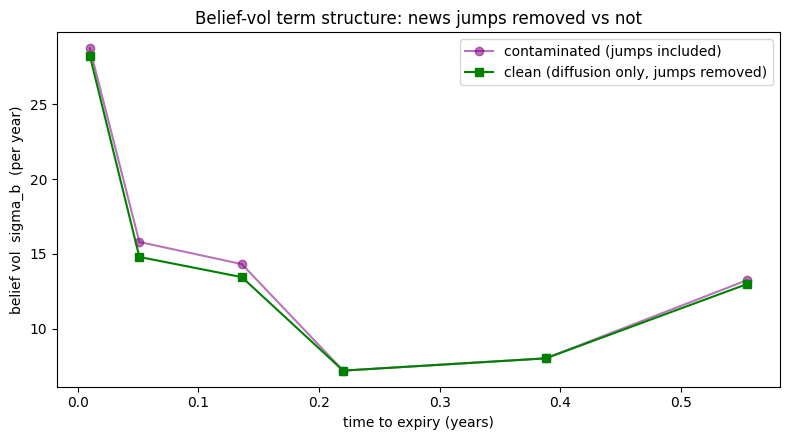

,label,tau_years,contaminated,clean,jump_lift_pct
0,June 15,0.01,28.73,28.23,1.7
1,June 30,0.05,15.79,14.79,6.3
2,July 31,0.14,14.31,13.44,6.1
3,August 31,0.22,7.19,7.19,0.0
4,October 31,0.39,8.01,8.01,0.0
5,December 31,0.56,13.24,12.98,2.0


In [16]:
import matplotlib.pyplot as plt

# (Point of integration) Demonstrate the wired flag: build_term_structure with
# use_clean_vol=True puts the DIFFUSION-ONLY vol into sigma_b. We pass the same
# CANDLE_LIMIT so it reproduces 11a's sigma_b_clean (same candles, same split).
clean_df = build_term_structure(fc, EVENT_ID, use_clean_vol=True,
                                clean_lookback_candles=CANDLE_LIMIT)
verify = (clean_df[["label", "sigma_b"]].rename(columns={"sigma_b": "build_ts_clean"})
          .merge(jump_summary[["label", "sigma_b_clean"]], on="label"))
print("use_clean_vol=True reproduces 11a's clean vol (up to live jitter):")
print(verify.round(2).to_string(index=False), "\n")

# Clean vs contaminated, strictly LIKE-FOR-LIKE: both come from 11a's single
# split_variance call over the same candles — 'contaminated' keeps the jumps
# (sigma_b_total), 'clean' removes them (sigma_b_clean). So clean <= contaminated
# by construction. We deliberately do NOT compare against df["sigma_b"] from
# section 3: that uses a different DOWN-SAMPLED 30-day method, so it sits on a
# different scale than the raw, de-jumped clean vol and would not be comparable.
m = jump_summary[["label", "tau_years", "sigma_b_total", "sigma_b_clean"]].rename(
    columns={"sigma_b_total": "contaminated", "sigma_b_clean": "clean"})

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(m["tau_years"], m["contaminated"], "o-", color="purple", alpha=0.55,
        label="contaminated (jumps included)")
ax.plot(m["tau_years"], m["clean"], "s-", color="green",
        label="clean (diffusion only, jumps removed)")
ax.set(xlabel="time to expiry (years)", ylabel="belief vol  sigma_b  (per year)",
       title="Belief-vol term structure: news jumps removed vs not")
ax.legend(); plt.tight_layout(); plt.show()

# Share of each deadline's vol that was actually news (>= 0 by construction):
m["jump_lift_pct"] = (100 * (m["contaminated"] - m["clean"]) / m["contaminated"]).round(1)
display(m.round(2))